In [1]:
#Librerias
import pandas as pd #Para lectura de datos
from sklearn.preprocessing import StandardScaler #Escalador de datos
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN #Algoritmos de clusterizado
from sklearn.metrics import silhouette_score, davies_bouldin_score #Métricas de compración: coeficiente silueta y davies bouldin
from sklearn.decomposition import PCA #Descomposición
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier #Algoritmos de vecinos
import matplotlib.pyplot as plt # Pyplot (gráficos)
import seaborn as sns #Predicción de limites
import numpy as np #Numpy

In [2]:
#Leer el data set de spreadsheets
df = pd.read_csv("dataset.csv", encoding="utf-8")
#df = pd.read_csv("https://docs.google.com/spreadsheets/d/14cR2_C6j1uNUNrzvTBFp7Is4rcAotjN2Bgm13ypDu7I/export?format=csv", encoding="utf-8")
df = df[df["AÑO"] == 2023] #Limitar los datos al año 2023 (Más reciente), para evitar desvordamiento de memoria.
df.head() #ver encabezado de los datos

,AÑO,DEPARTAMENTO,MUNICIPIO,CABECERA MUNICIPAL,CENTRO POBLADO,COBERTURA 2G,COBERTURA 3G,"COBERTURA HSPA+, HSPA+DC",COBERTUTA 4G,COBERTURA LTE,COBERTURA 5G
0,2023,CHOCÓ,EL LITORAL DEL SAN JUAN,0,TORDÓ,0,0,0,1,0,0
1,2023,ANTIOQUIA,NECHÍ,0,LA CONCHA,1,1,1,1,0,0
9,2023,BOYACÁ,CHINAVITA,1,CHINAVITA,0,1,1,0,0,0
31,2023,BOLÍVAR,MAHATES,0,SAN BASILIO DE PALENQUE,0,1,1,1,0,0
35,2023,CUNDINAMARCA,RICAURTE,1,RICAURTE,1,1,1,1,0,0


In [3]:
#Obtner las columnas principales (redes móviles)
X = df[[
    "CABECERA MUNICIPAL",
    "COBERTURA 2G",
    "COBERTURA 3G",
    "COBERTURA HSPA+, HSPA+DC",
    "COBERTUTA 4G"
]]
#Verificar selección
X.info()
X.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 33005 entries, 0 to 127269
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   CABECERA MUNICIPAL        33005 non-null  int64
 1   COBERTURA 2G              33005 non-null  int64
 2   COBERTURA 3G              33005 non-null  int64
 3   COBERTURA HSPA+, HSPA+DC  33005 non-null  int64
 4   COBERTUTA 4G              33005 non-null  int64
dtypes: int64(5)
memory usage: 1.5 MB


,CABECERA MUNICIPAL,COBERTURA 2G,COBERTURA 3G,"COBERTURA HSPA+, HSPA+DC",COBERTUTA 4G
count,33005.000000,33005.000000,33005.000000,33005.000000,33005.000000
mean,0.401030,0.617391,0.774034,0.719436,0.741766
std,0.490115,0.486031,0.418223,0.449281,0.437670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


# Análisis de k

En el bloque de abajo se realiza el método del codo, con el fin de obtener el número óptimo de clústeres para el cúmulo de datos. 

## K- mens

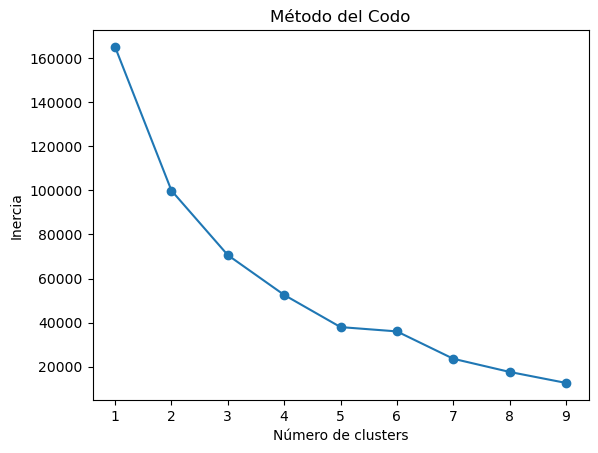

In [4]:
#Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# K-means con método del codo
# El número
inertia = []
k_range = range(1,10) #Probar 10 clusters
#iterar en el rango de clusters
for k in k_range:
    kmeans = KMeans(n_clusters=k,n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
#mostrar gráfica de la inercia (distancias desde el centroide)
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

## Dbscan

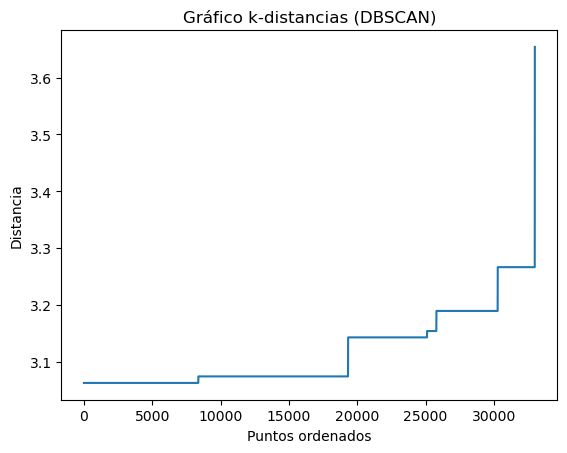

In [5]:
#Gráfico de k-distancias
# k = min_samples
k = 10
neighbors = NearestNeighbors(n_neighbors=k)
X_unique = pd.DataFrame(X_scaled).drop_duplicates() #eliminar duplicados
neighbors_fit = neighbors.fit(X_unique)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = distances[:, k-1]
distances = np.sort(distances)
plt.plot(distances)
plt.title("Gráfico k-distancias (DBSCAN)")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia")
plt.show()

In [6]:
#Tabla con la información de eps
#Rango de valores de eps (epsilon); 
eps_values = [2.0,2.1,2.2,2.3,2.4]
resultados = []
#Iterar eps para encontrar el mejor
for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=k)
    labels = db.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    ruido = list(labels).count(-1)
    resultados.append({
        "eps": eps,
        "clusters": n_clusters,
        "ruido": ruido
    })
tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

,eps,clusters,ruido
0,2.0,19,17
1,2.1,6,12
2,2.2,6,12
3,2.3,2,6
4,2.4,1,0


## Jerárquico

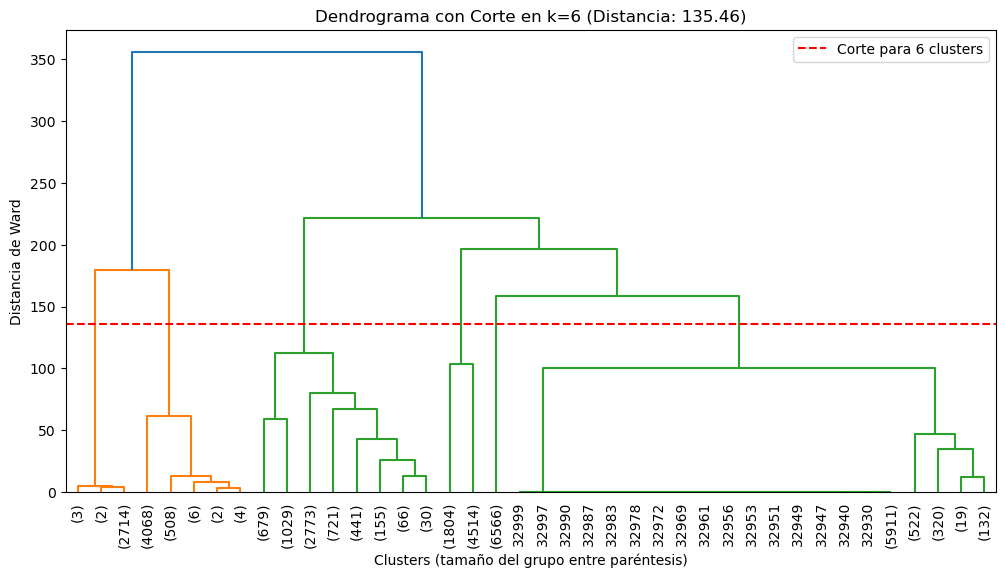

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')
k = 6 #Número de clusters óptimo
# El corte óptimo
corte_y = (Z[-k, 2] + Z[-(k-1), 2]) / 2
plt.figure(figsize=(12, 6))
# Graficar el dendrograma
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=90., leaf_font_size=10.)
# Dibujar la línea dinámica
plt.axhline(y=corte_y, color='r', linestyle='--', label=f'Corte para {k} clusters')
plt.title(f"Dendrograma con Corte en k={k} (Distancia: {corte_y:.2f})")
plt.xlabel("Clusters (tamaño del grupo entre paréntesis)")
plt.ylabel("Distancia de Ward")
plt.legend()
plt.show()

# Clusterización

## K-meas


In [8]:
#Agrupar en 4 clusters
kmeans = KMeans(n_clusters=4,n_init="auto", random_state=42) # 4 son los clusters optimos
kmeans_labels = kmeans.fit_predict(X_scaled)
df["cluster_kmeans"] = kmeans_labels

## DB scan

In [9]:
# Ejecución de dbscan (2.3)
dbscan = DBSCAN(eps=2.3, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
df["cluster_dbscan"] = dbscan_labels

## Jerárquico

In [39]:
#Clustering jerárquico
hierarchical = AgglomerativeClustering(n_clusters=6)
hierarchical_labels = hierarchical.fit_predict(X_scaled)
df["cluster_hierarchical"] = hierarchical_labels

# Gráficos de los clusters

In [ ]:
pca = PCA(n_components=2)
df = df.reset_index(drop=True)
X_pca = pca.fit_transform(X_scaled)
# Crear dataframe para graficar
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["kmeans"] = kmeans_labels
df_pca["dbscan"] = dbscan_labels
df_pca["hierarchical"] = hierarchical_labels

## K-means

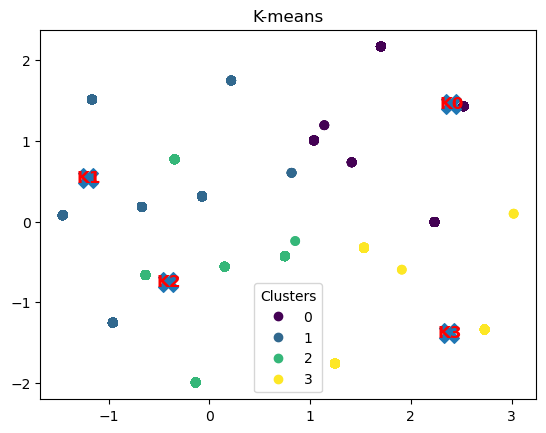

In [38]:
#Obtener centroides
centroids = pca.transform(kmeans.cluster_centers_)
# Graficar
plt.figure()
scatter = plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["kmeans"])
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)
plt.title("K-means")
#Etiquetas
for i, (x, y) in enumerate(centroids):
    plt.text(x, y, f'K{i}', fontsize=12, ha='center', va='center',color='red',weight='bold')
plt.show()

In [19]:
#Tabla
df.groupby("cluster_kmeans")[[
    "CABECERA MUNICIPAL",
    "COBERTURA 2G",
    "COBERTURA 3G",
    "COBERTURA HSPA+, HSPA+DC",
    "COBERTUTA 4G"
]].mean()

,CABECERA MUNICIPAL,COBERTURA 2G,COBERTURA 3G,"COBERTURA HSPA+, HSPA+DC",COBERTUTA 4G
cluster_kmeans,,,,,
0,0.109860,0.031478,0.013759,0.000834,1.000000
1,1.000000,0.560951,0.999528,0.956559,0.865114
2,0.000000,0.811440,0.999832,0.973123,0.730052
3,0.000556,0.956050,0.243672,0.000000,0.000000


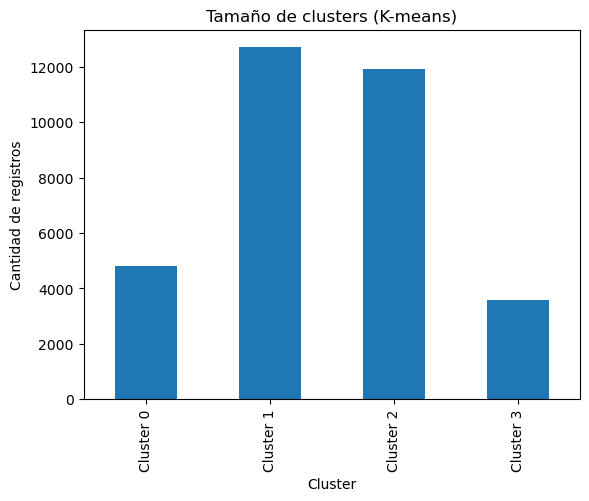

In [16]:
cluster_counts = df["cluster_kmeans"].value_counts().sort_index()
cluster_percent = df["cluster_kmeans"].value_counts(normalize=True).sort_index() * 100
tabla_clusters = pd.DataFrame({
    "Cantidad": cluster_counts,
    "Porcentaje (%)": cluster_percent.round(2)
})
tabla_clusters.index = [f"Cluster {i}" for i in tabla_clusters.index]
tabla_clusters["Cantidad"].plot(kind="bar")
plt.title("Tamaño de clusters (K-means)")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de registros")
plt.show()

## Dbscan

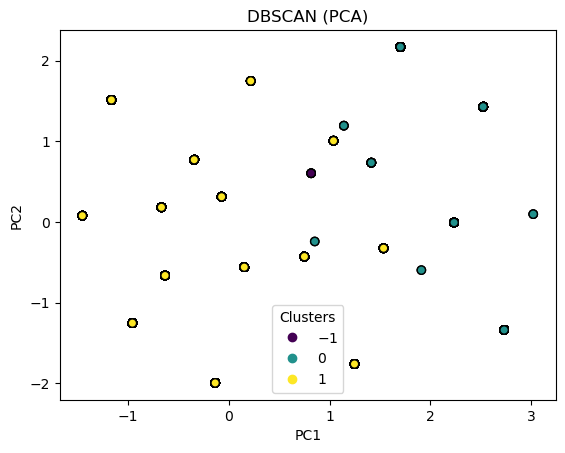

In [34]:
# Graficar
plt.figure()
# puntos normales
scatter = plt.scatter(
    df_pca["PC1"], 
    df_pca["PC2"], 
    c=df_pca["dbscan"], 
    edgecolor='k'
)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("DBSCAN (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [21]:
#Tabla
df.groupby("cluster_dbscan")[[
    "CABECERA MUNICIPAL",
    "COBERTURA 2G",
    "COBERTURA 3G",
    "COBERTURA HSPA+, HSPA+DC",
    "COBERTUTA 4G"
]].mean()

,CABECERA MUNICIPAL,COBERTURA 2G,COBERTURA 3G,"COBERTURA HSPA+, HSPA+DC",COBERTUTA 4G
cluster_dbscan,,,,,
-1,1.000000,0.000000,0.0,1.000000,0.000000
0,0.070988,0.384997,0.0,0.000805,0.635132
1,0.497162,0.685325,1.0,0.928994,0.773046


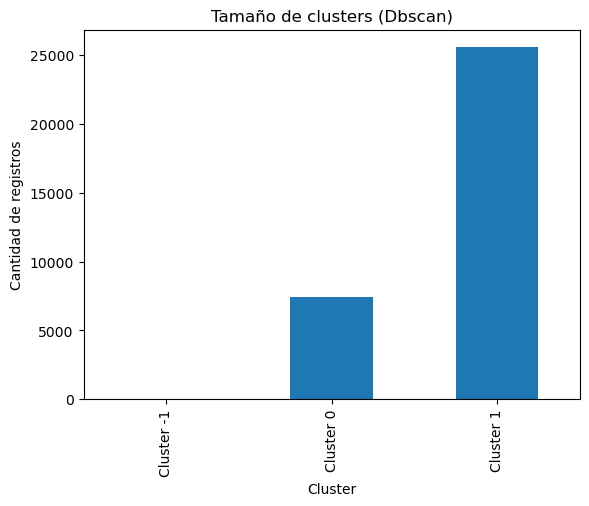

In [22]:
cluster_counts = df["cluster_dbscan"].value_counts().sort_index()
cluster_percent = df["cluster_dbscan"].value_counts(normalize=True).sort_index() * 100
tabla_clusters = pd.DataFrame({
    "Cantidad": cluster_counts,
    "Porcentaje (%)": cluster_percent.round(2)
})
tabla_clusters.index = [f"Cluster {i}" for i in tabla_clusters.index]
tabla_clusters["Cantidad"].plot(kind="bar")
plt.title("Tamaño de clusters (Dbscan)")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de registros")
plt.show()

## Jerárquico

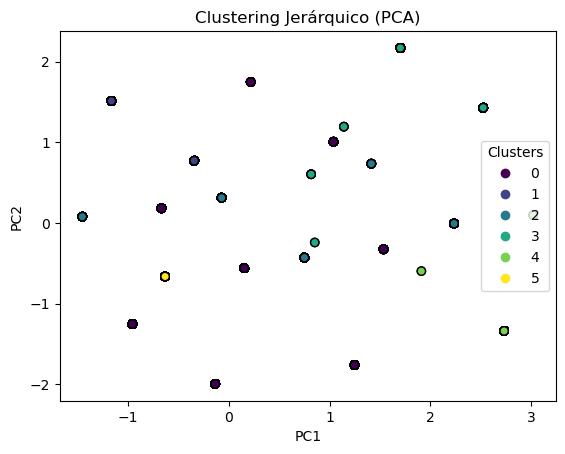

In [23]:
# Graficar
df = df.reset_index(drop=True)
plt.figure()
scatter = plt.scatter(
    df_pca["PC1"],
    df_pca["PC2"],
    c=df_pca["hierarchical"],
    edgecolor='k'
)
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.title("Clustering Jerárquico (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [24]:
#Tabla
df.groupby("cluster_hierarchical")[[
    "CABECERA MUNICIPAL",
    "COBERTURA 2G",
    "COBERTURA 3G",
    "COBERTURA HSPA+, HSPA+DC",
    "COBERTUTA 4G"
]].mean()

,CABECERA MUNICIPAL,COBERTURA 2G,COBERTURA 3G,"COBERTURA HSPA+, HSPA+DC",COBERTUTA 4G
cluster_hierarchical,,,,,
0,0.294876,0.708008,1.000000,0.835087,0.016288
1,0.714467,0.000000,1.000000,1.000000,1.000000
2,0.934682,1.000000,0.978179,0.856503,1.000000
3,0.112031,0.000436,0.000000,0.002616,0.998692
4,0.000736,0.998897,0.000000,0.000000,0.000000
5,0.000000,1.000000,1.000000,1.000000,1.000000


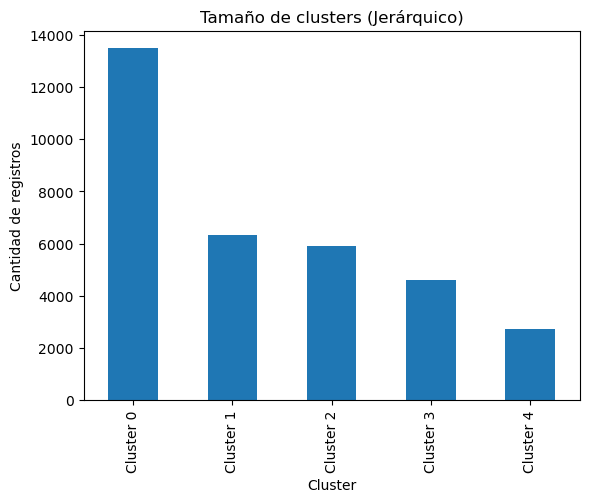

In [40]:
cluster_counts = df["cluster_hierarchical"].value_counts().sort_index()
cluster_percent = df["cluster_hierarchical"].value_counts(normalize=True).sort_index() * 100
tabla_clusters = pd.DataFrame({
    "Cantidad": cluster_counts,
    "Porcentaje (%)": cluster_percent.round(2)
})
tabla_clusters.index = [f"Cluster {i}" for i in tabla_clusters.index]
tabla_clusters["Cantidad"].plot(kind="bar")
plt.title("Tamaño de clusters (Jerárquico)")
plt.xlabel("Cluster")
plt.ylabel("Cantidad de registros")
plt.show()

# Métricas de los coeficiente silueta y davies bouldin

In [26]:
#Metricas
# K-Means
print("K-Means")
print("Silhouette:", silhouette_score(X_scaled, kmeans_labels))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, kmeans_labels))
# DBSCAN
print("\nDBSCAN")
print("Silhouette:", silhouette_score(X_scaled, dbscan_labels))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, dbscan_labels))
# Jerárquico
print("\nHierarchical")
print("Silhouette:", silhouette_score(X_scaled, hierarchical_labels))
print("Davies-Bouldin:", davies_bouldin_score(X_scaled, hierarchical_labels))

K-Means
Silhouette: 0.5435080145026242
Davies-Bouldin: 0.8683979280751382

DBSCAN
Silhouette: 0.4102421354672087
Davies-Bouldin: 0.8134732089703963

Hierarchical
Silhouette: 0.7103522451236154
Davies-Bouldin: 0.66058504802678
